In [1]:
%matplotlib notebook

# import cv2  # python OpenCV
import os  # 
import numpy as np  # lib for arrays
import datetime
import glob
import pandas as pd

import math as mh  # math package

import matplotlib as mpl  
import matplotlib.pyplot as plt  # namespace for plotting
mpl.rcParams['figure.figsize'] = (6,5)  # change default value of plot size

# matplotlib based package for pretty visualization
import seaborn as sns

import time
import pickle  # package for dump & load data
import warnings

In [2]:
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [3]:
df_grouped = pd.crosstab(tips['sex'], (tips['tip'] > 0)) # количество заплативших чаевые среди женщин и мужчин
df_grouped

tip,True
sex,
Male,157
Female,87


In [4]:
sm_1 = tips['smoker'].value_counts(sort=False) #для самопроверки
sm_1

Yes     93
No     151
Name: smoker, dtype: int64

In [5]:
sm_2=pd.crosstab(tips.sex, tips.smoker,margins=True) #группировка данных
sm_2

smoker,Yes,No,All
sex,,,
Male,60,97,157
Female,33,54,87
All,93,151,244


In [6]:

pr_f=sm_2.iloc[1]['Yes']/sm_2.iloc[1]['All'] 
pr_m=sm_2.iloc[0]['Yes']/sm_2.iloc[1]['All']

print (pr_f)               # Доля курящих среди женщин
pr_m                       # Доля курящих среди женщин


0.3793103448275862


0.6896551724137931

In [7]:
tips.loc[tips['size'].idxmax()] #просто метод потестила

total_bill      29.8
tip              4.2
sex           Female
smoker            No
day             Thur
time           Lunch
size               6
Name: 125, dtype: object

In [8]:
tips.groupby(by='day')['size'].mean() #день с наибольшим количеством посетителей

day
Thur    2.451613
Fri     2.105263
Sat     2.517241
Sun     2.842105
Name: size, dtype: float64

In [9]:
tips.groupby(by='time')['tip'].max()  #наибольшее количество чаевых

time
Lunch      6.7
Dinner    10.0
Name: tip, dtype: float64

In [10]:
max_row=np.argmax(tips['total_bill'].values) 
tips['day'].values[max_row]          #заказ с максимальным счетом

'Sat'

In [11]:
gr_1=tips [['day','total_bill','smoker']]  #серия действий для построения графика
gr_1



,day,total_bill,smoker
0,Sun,16.99,No
1,Sun,10.34,No
2,Sun,21.01,No
3,Sun,23.68,No
4,Sun,24.59,No
5,Sun,25.29,No
6,Sun,8.77,No
7,Sun,26.88,No
8,Sun,15.04,No
9,Sun,14.78,No


In [12]:
gr_1['smoker'].unique().tolist()

['No', 'Yes']

In [13]:
anti_smokers=gr_1.loc[gr_1['smoker']=='No']
anti_smokers


,day,total_bill,smoker
0,Sun,16.99,No
1,Sun,10.34,No
2,Sun,21.01,No
3,Sun,23.68,No
4,Sun,24.59,No
5,Sun,25.29,No
6,Sun,8.77,No
7,Sun,26.88,No
8,Sun,15.04,No
9,Sun,14.78,No


In [14]:
asm=anti_smokers.groupby(by='day')['total_bill'].median()
asm


day
Thur    15.950
Fri     19.235
Sat     17.820
Sun     18.430
Name: total_bill, dtype: float64

In [15]:
smokers=gr_1.loc[gr_1['smoker']=="Yes"]
smokers

,day,total_bill,smoker
56,Sat,38.01,Yes
58,Sat,11.24,Yes
60,Sat,20.29,Yes
61,Sat,13.81,Yes
62,Sat,11.02,Yes
63,Sat,18.29,Yes
67,Sat,3.07,Yes
69,Sat,15.01,Yes
72,Sat,26.86,Yes
73,Sat,25.28,Yes


In [16]:
sm=smokers.groupby(by='day')['total_bill'].median()
sm

day
Thur    16.47
Fri     13.42
Sat     20.39
Sun     23.10
Name: total_bill, dtype: float64

In [17]:
hist = pd.concat([asm,sm], axis=1)
hist

,total_bill,total_bill
day,,
Thur,15.950,16.47
Fri,19.235,13.42
Sat,17.820,20.39
Sun,18.430,23.10


In [18]:
hist.columns.values[0] = "good_lungs"
hist.columns.values[1] = "not_so_good"
hist

,good_lungs,not_so_good
day,,
Thur,15.950,16.47
Fri,19.235,13.42
Sat,17.820,20.39
Sun,18.430,23.10


<IPython.core.display.Javascript object>


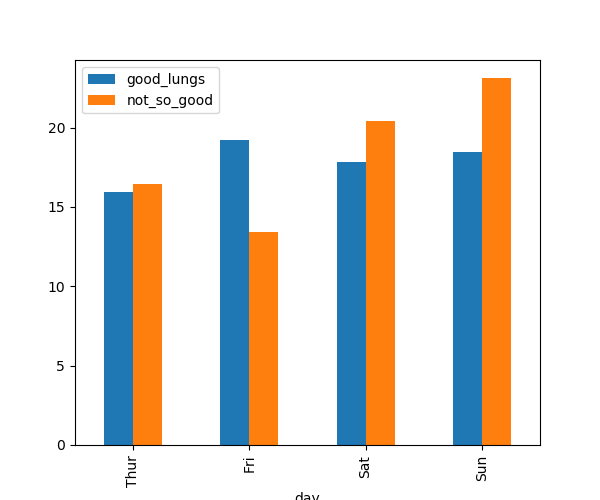

In [19]:
hist.groupby('day').sum().plot(kind='bar')